# 01 - Data Acquisition & Cleaning

**Project:** ARMA-GARCH Beta Risk Model  
**Author:** Amos Anderson  
**Purpose:** Download daily price data for all asset classes, verify data
integrity, compute log returns, and save processed data to `data/processed/`.

All reusable functions are implemented in `src/data_utils.py` and imported here.
The notebook documents decisions and shows diagnostic plots.

In [1]:
import sys
from pathlib import Path

# Make src/ importable from the notebooks/ directory
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Plot style
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Imports OK")

Imports OK


----

## Asset selection

Five asset classes are included to stress-test the model across different return distributions and volatility regimes:

| Ticker | Name | Asset class |
|--------|------|-------------|
| ^GSPC | S&P 500 | Equity index (required benchmark) |
| AAPL | Apple Inc. | Large-cap single stock |
| GLD | SPDR Gold ETF | Commodity proxy |
| TIP | iShares TIPS ETF | Inflation-protected fixed income |
| EURUSD=X | EUR/USD | Foreign exchange |

Date range: 2005-01-01 to 2025-12-31 (20 years, ~5,000 trading days).

Estimation window: 250 periods. Assessment window: 1,000 periods.

Minimum required: 1,250 periods. All assets exceed this comfortably.

In [3]:
# Implement src/data_utils.py

from src.data_utils import (
    download_prices,
    check_corporate_actions,
    compute_log_returns,
    summary_statistics,
    save_processed,
    load_processed,
)
print("src.data_utils imported OK")

src.data_utils imported OK


In [4]:
# Download prices

TICKERS = ["^GSPC", "AAPL", "GLD", "TIP", "EURUSD=X"]
START   = "2005-01-01"
END     = "2025-12-31"

prices = download_prices(TICKERS, start=START, end=END)
prices.head()

Downloaded 5 tickers × 5474 days


Ticker,AAPL,EURUSD=X,GLD,TIP,^GSPC
Date,,,,,
2005-01-03,0.948180,1.347001,43.020000,55.212532,1202.079956
2005-01-04,0.957918,1.328198,42.740002,54.831493,1188.050049
2005-01-05,0.966307,1.328004,42.669998,54.768829,1183.739990
2005-01-06,0.967056,1.318305,42.150002,54.857563,1187.890015
2005-01-07,1.037469,1.306097,41.840000,54.716656,1186.189941


In [6]:
# Corporate action check

flags = check_corporate_actions(prices)

Corporate action check PASSED - no suspicious jumps detected


In [7]:
# Missing data audit

missing = prices.isna().sum()
print("Missing values per ticker:")
print(missing)
print(f"\nTotal missing: {missing.sum()}")

Missing values per ticker:
Ticker
AAPL        192
EURUSD=X     29
GLD         192
TIP         192
^GSPC       192
dtype: int64

Total missing: 797


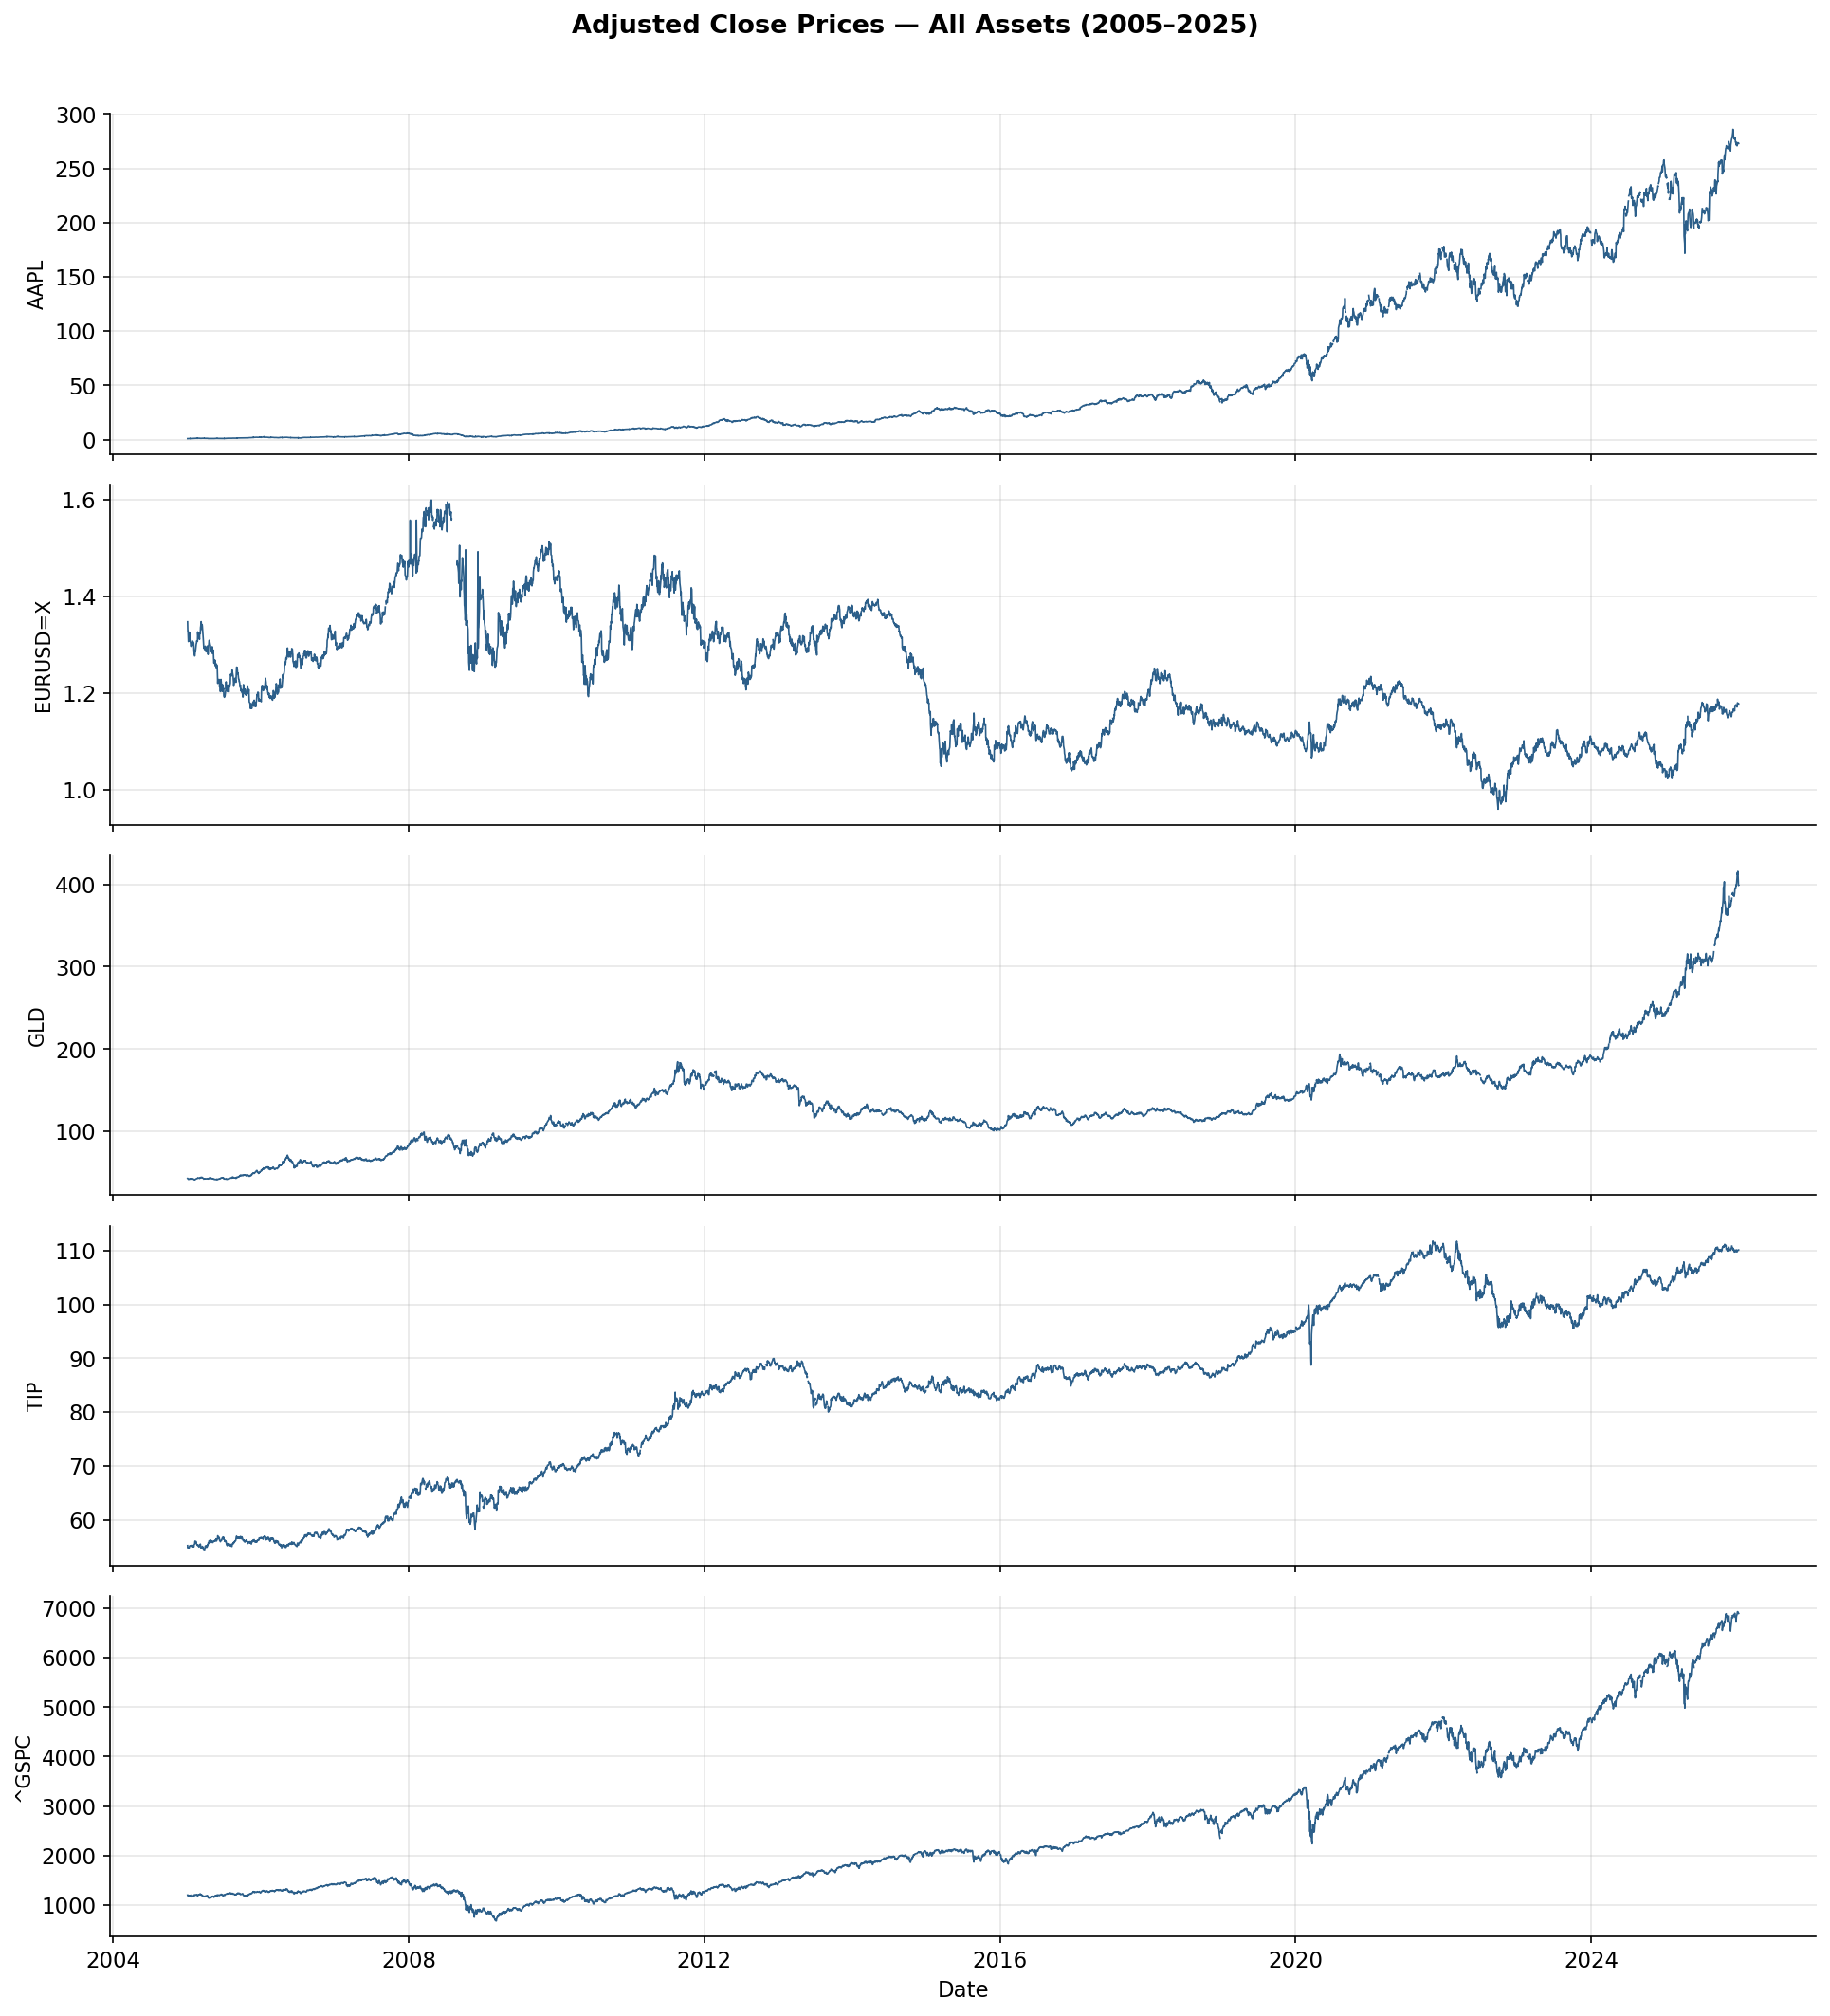

Figure saved to outputs/figures/01_raw_prices.png


In [21]:
# Plot raw price series

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(13, 14), sharex=True)

for ax, ticker in zip(axes, prices.columns):
    ax.plot(prices.index, prices[ticker], linewidth=0.8, color="#2c5f8a")
    ax.set_ylabel(ticker, fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[-1].set_xlabel("Date")
fig.suptitle("Adjusted Close Prices — All Assets (2005–2025)", 
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/01_raw_prices.png", bbox_inches="tight")
plt.show()
print("Figure saved to outputs/figures/01_raw_prices.png")

In [10]:
# Compute log returns

returns = compute_log_returns(prices)
returns.head()

Log returns shape: (5047, 5)


Ticker,AAPL,EURUSD=X,GLD,TIP,^GSPC
Date,,,,,
2005-01-04,0.010218,-0.014058,-0.006530,-0.006925,-0.011740
2005-01-05,0.008720,-0.000146,-0.001639,-0.001144,-0.003634
2005-01-06,0.000775,-0.007330,-0.012261,0.001619,0.003500
2005-01-07,0.070282,-0.009303,-0.007382,-0.002572,-0.001432
2005-01-10,-0.004196,0.003743,0.002626,0.000668,0.003417


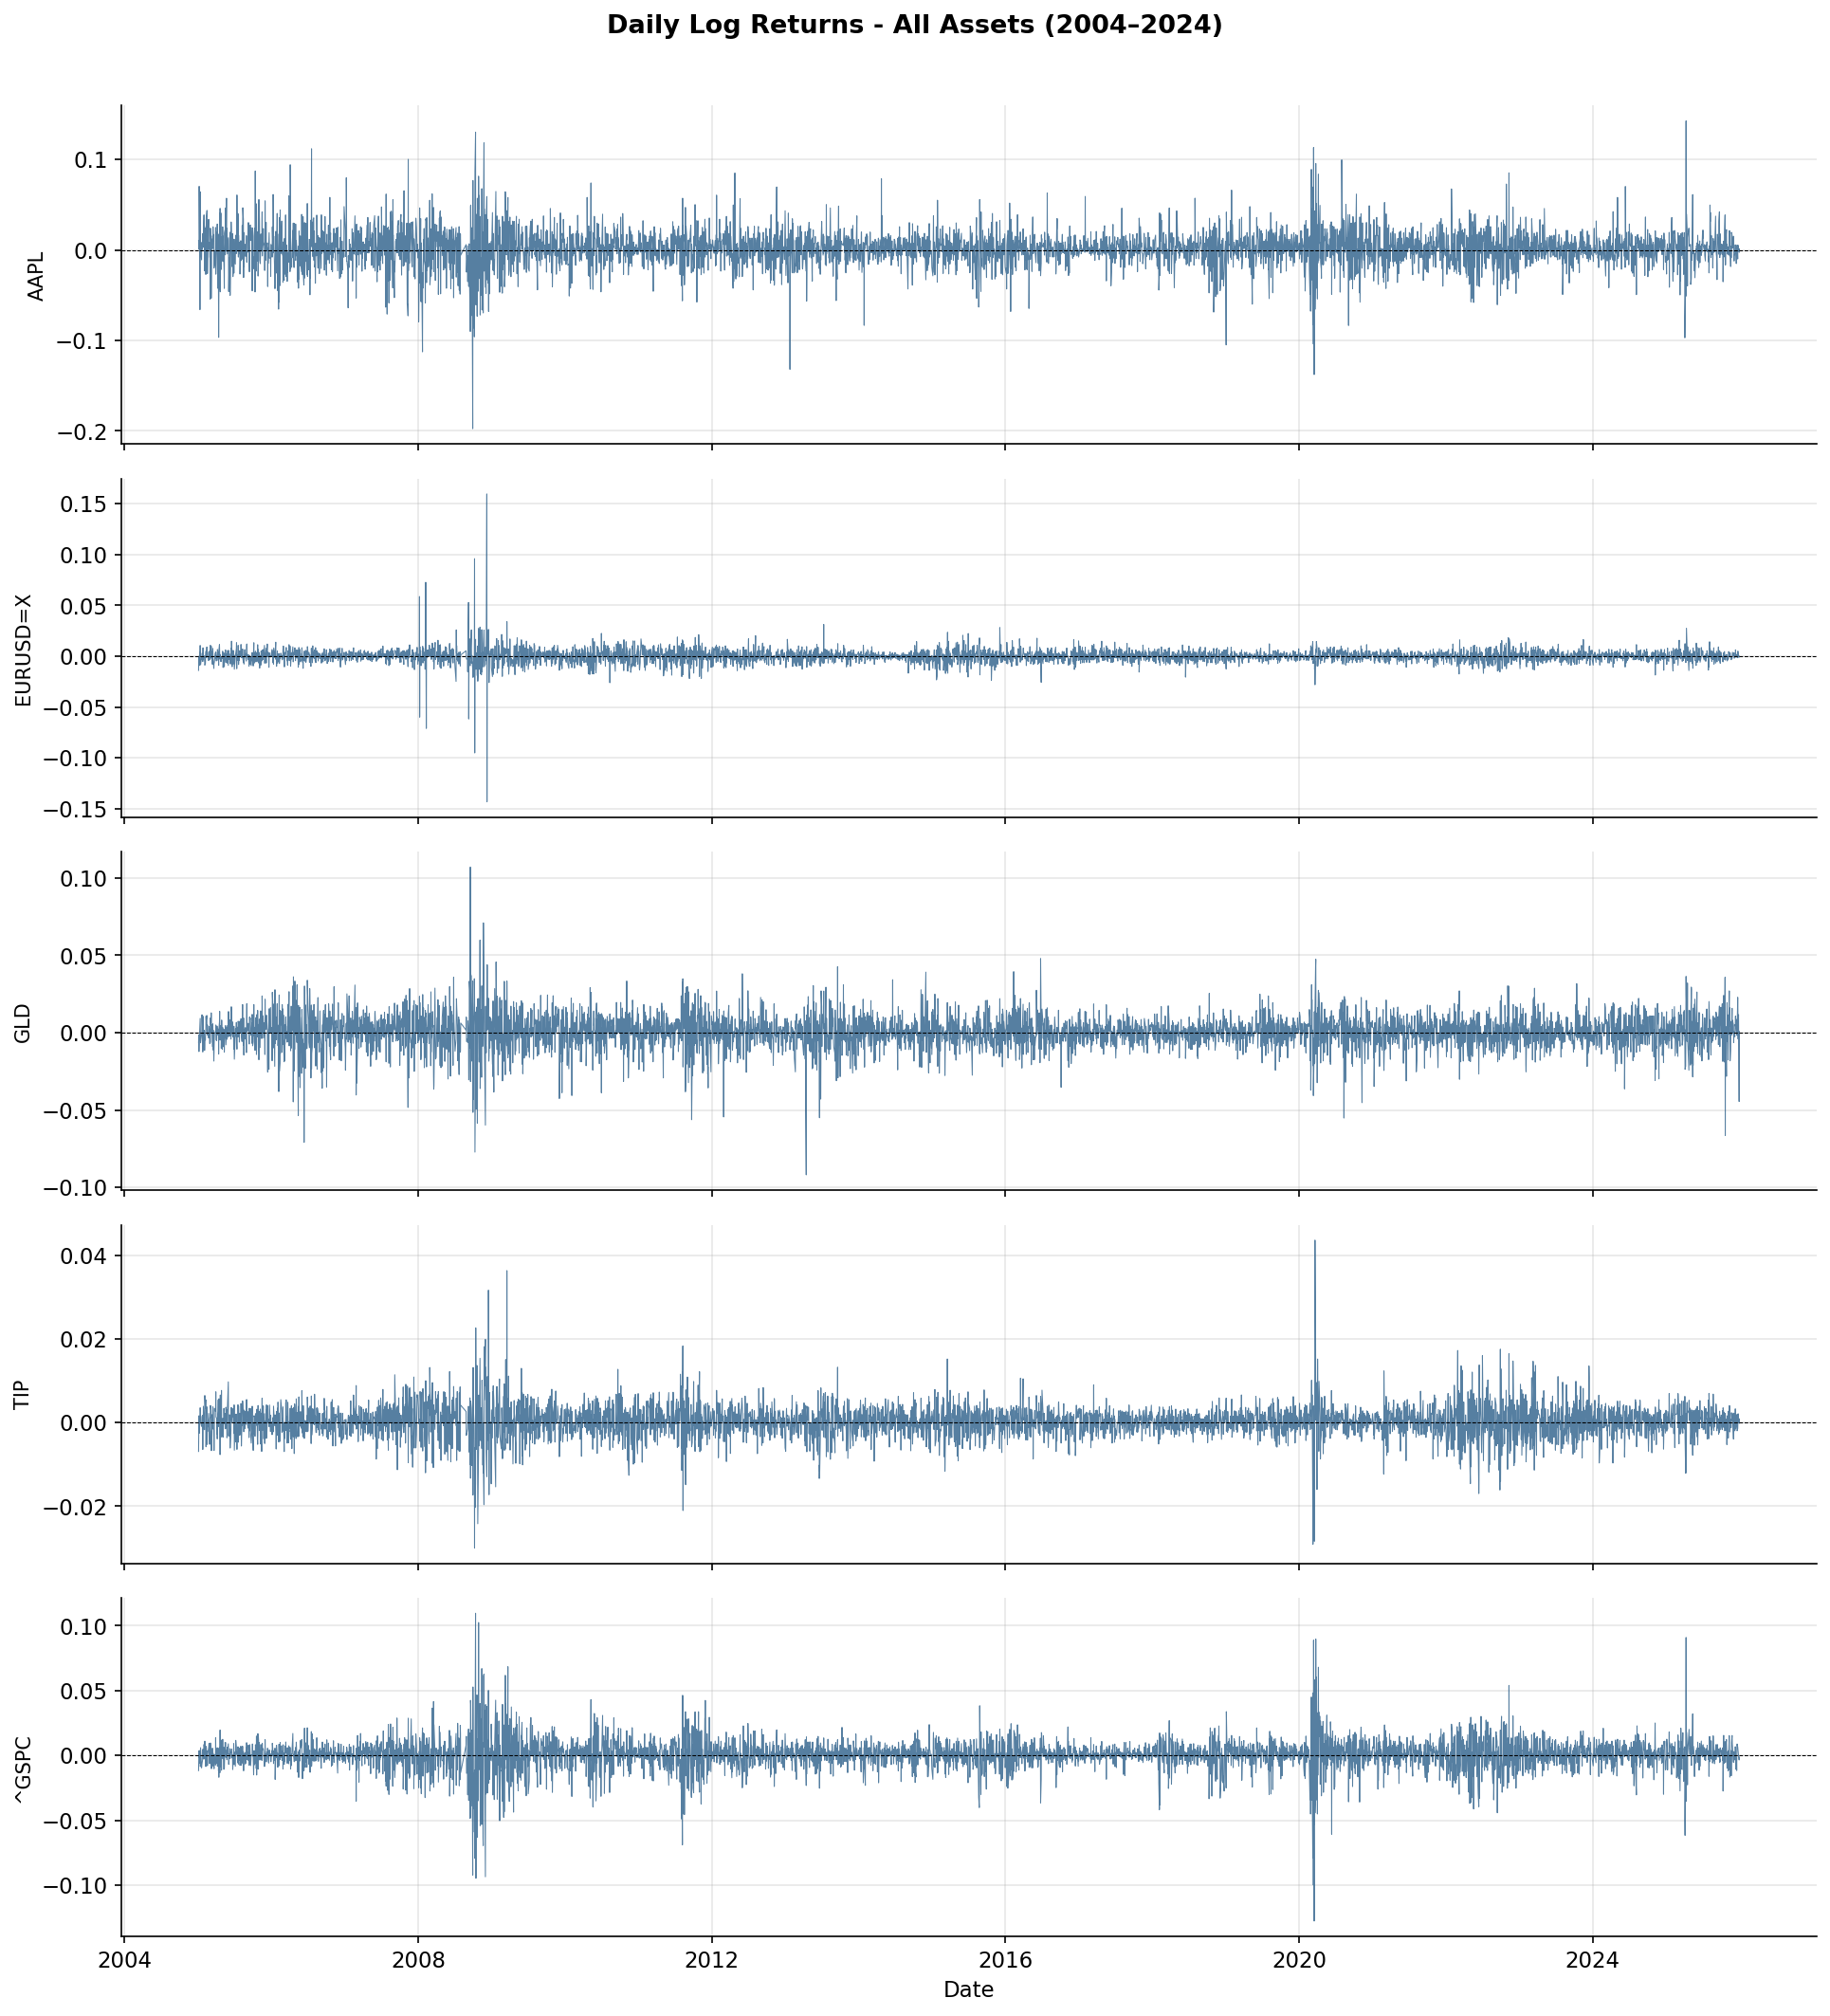

Figure saved to outputs/figures/01_log_returns.png


In [12]:
# Plot return series

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(13, 14), sharex=True)

for ax, ticker in zip(axes, returns.columns):
    ax.plot(returns.index, returns[ticker], linewidth=0.5, color="#2c5f8a", alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_ylabel(ticker, fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[-1].set_xlabel("Date")
fig.suptitle("Daily Log Returns - All Assets (2004–2024)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/01_log_returns.png", bbox_inches="tight")
plt.show()
print("Figure saved to outputs/figures/01_log_returns.png")

In [13]:
# Summary Statistics

stats = summary_statistics(returns)
print("Summary Statistics\n")
print(stats.round(4).to_string())

Summary Statistics

Ticker                AAPL   EURUSD=X        GLD        TIP      ^GSPC
mean (daily)        0.0010     0.0000     0.0004     0.0001     0.0003
std (daily)         0.0202     0.0071     0.0111     0.0039     0.0121
mean (annual)       0.2595     0.0028     0.0928     0.0366     0.0858
vol (annual)        0.3206     0.1127     0.1755     0.0619     0.1922
skewness           -0.2255     0.6255    -0.3433     0.1923    -0.4895
excess kurtosis     6.4455   104.1244     6.3024    10.0030    13.6071
min                -0.1975    -0.1433    -0.0919    -0.0300    -0.1277
max                 0.1426     0.1596     0.1070     0.0436     0.1096
obs              5047.0000  5047.0000  5047.0000  5047.0000  5047.0000


---

## Interpreting the summary statistics

Key quantities to note before proceeding:

- **Excess kurtosis** -- all assets should show values well above 0 (the Gaussian
  baseline). Values of 3-15 are typical for daily equity returns. This is the
  primary empirical justification for using NIG over a Gaussian model.
- **Skewness** -- negative skewness (left tail heavier) is typical for equities,
  consistent with crash risk being larger than equivalent upside moves.
- **Volatility clustering** -- visible in the return plots as alternating calm and
  turbulent periods. ARMA-GARCH in notebook 02 is designed specifically to
  remove this feature from the innovations.

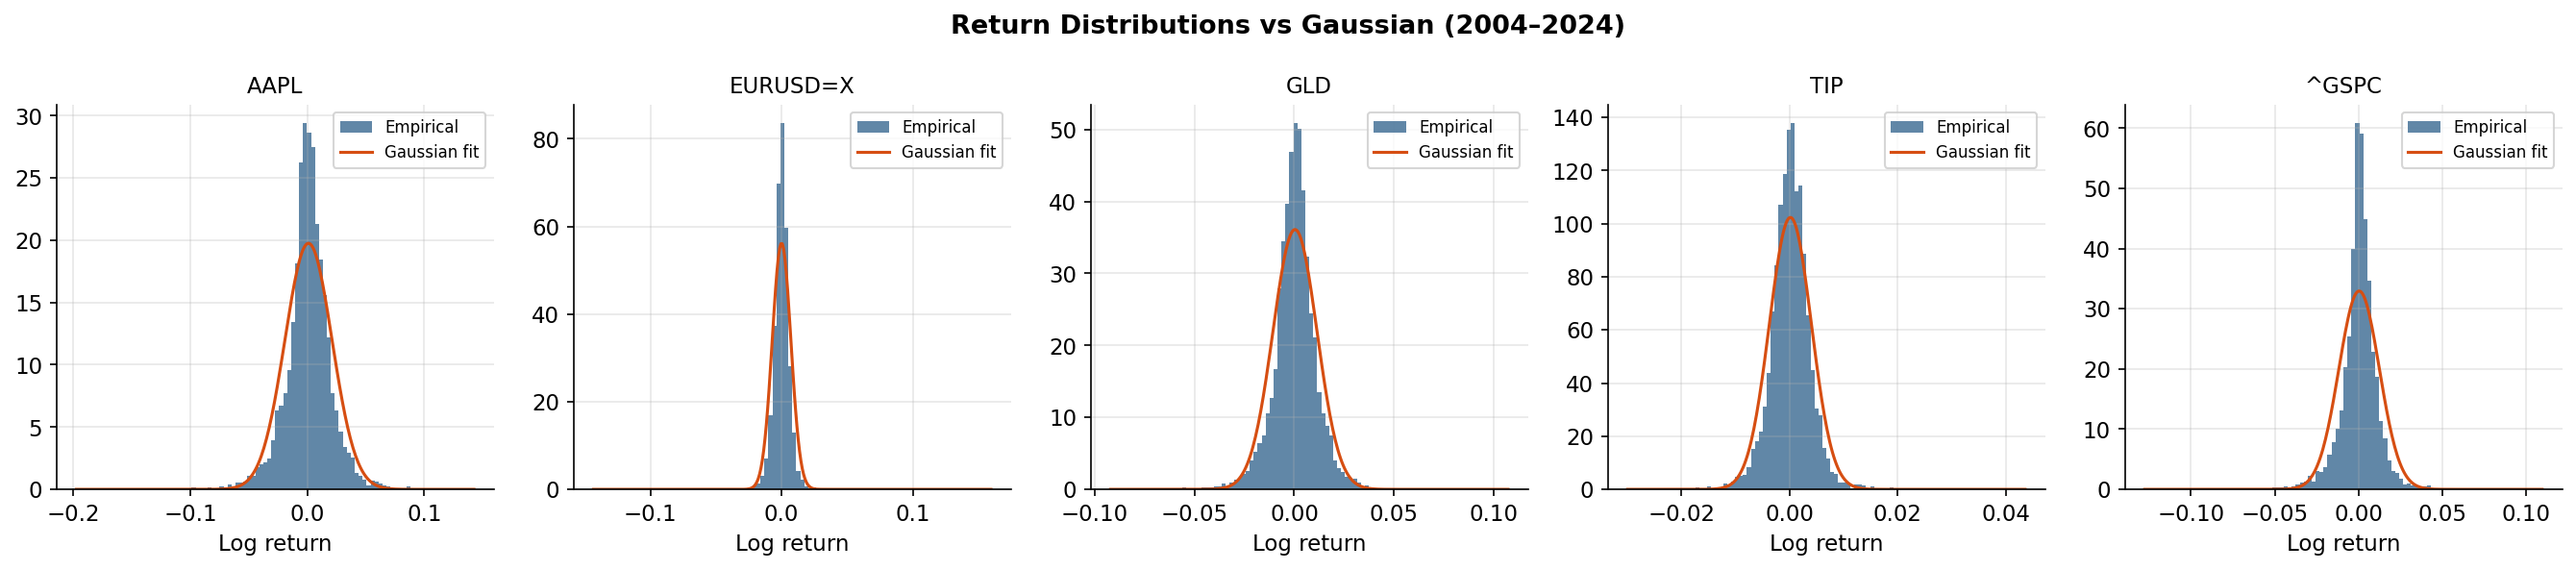

Figure saved to outputs/figures/01_return_distributions.png


In [14]:
# Return distribution plots

fig, axes = plt.subplots(1, len(TICKERS), figsize=(18, 4))

for ax, ticker in zip(axes, returns.columns):
    data = returns[ticker].dropna()
    ax.hist(data, bins=100, color="#2c5f8a", alpha=0.75, density=True, label="Empirical")

    # Overlay a Gaussian with same mean and std for comparison
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 300)
    gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    ax.plot(x, gaussian, color="#d64e12", linewidth=1.5, label="Gaussian fit")

    ax.set_title(ticker, fontsize=11)
    ax.set_xlabel("Log return")
    ax.legend(fontsize=8)

fig.suptitle("Return Distributions vs Gaussian (2004–2024)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/01_return_distributions.png", bbox_inches="tight")
plt.show()
print("Figure saved to outputs/figures/01_return_distributions.png")

In [15]:
# Save processed data

save_processed(prices,  "prices.parquet")
save_processed(returns, "returns.parquet")
print("\nAll processed data saved.")

Saved → C:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\arma-garch-beta-risk-model\data\processed\prices.parquet
Saved → C:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\arma-garch-beta-risk-model\data\processed\returns.parquet

All processed data saved.


In [19]:
# Verification round trip

returns_check = load_processed("returns.parquet")
assert returns_check.shape == returns.shape, "Shape mismatch — file not saved correctly"
assert returns_check.isna().sum().sum() == 0, "NaNs found in saved returns"
print(f"Verification PASSED — {returns_check.shape[0]} periods, {returns_check.shape[1]} assets")
print(f"Date range: {returns_check.index[0].date()} to {returns_check.index[-1].date()}")

Loaded ← C:\Users\amosa\Documents\My Graduate School\SPRING 2026\Courses\AMS603_Risk Measures for Finance and Data Analysis\Projects\arma-garch-beta-risk-model\data\processed\returns.parquet  shape=(5047, 5)
Verification PASSED — 5047 periods, 5 assets
Date range: 2005-01-04 to 2025-12-30


----

## Handoff to notebook 02

The following files are now saved in `data/processed/`:

- `prices.parquet` -- adjusted close prices, all tickers
- `returns.parquet` -- daily log returns, all tickers, NaN-free

**notebook 02** (`02_arma_garch.ipynb`) loads `returns.parquet` and fits
ARMA(1,1)-GARCH(1,1) in a 250-period rolling window across 1,000 assessment
periods, extracting standardised innovations for NIG fitting in notebook 03.


---